## Imputation


In [16]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from scipy import stats
import pandas as pd



def conditional_knn_impute_alcohol(X_train, X_cair, n_neighbors=5):
    """
    For each CAIR patient, find K nearest neighbors in training data
    based on Smoking and Physical Activity, then assign alcohol based
    on those neighbors' alcohol values
    """
    
    # Features to use for finding neighbors (exclude alcohol)
    neighbor_features = ['Smoking Status', 'Physical Activity']
    
    # Fit KNN on training data
    knn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    knn.fit(X_train[neighbor_features])
    
    # Find neighbors for each CAIR patient
    distances, indices = knn.kneighbors(X_cair[neighbor_features])
    
    # Impute alcohol values
    X_cair_imputed = X_cair.copy()
    alcohol_imputed = []
    
    for i, neighbor_indices in enumerate(indices):
        # Get alcohol values of K nearest neighbors
        neighbor_alcohol = X_train.iloc[neighbor_indices]['Alcohol Intake'].values
        
        # Method A: Take mean (can be fractional)
        imputed_value = np.mean(neighbor_alcohol)
        
        # Method B: Take mode (most common value - more realistic)
        # from scipy import stats
        # imputed_value = stats.mode(neighbor_alcohol, keepdims=True)[0][0]
        
        # Method C: Weighted by distance (closer neighbors have more influence)
        weights = 1 / (distances[i] + 1e-5)  # Avoid division by zero
        imputed_value = np.average(neighbor_alcohol, weights=weights)
        
        alcohol_imputed.append(imputed_value)
    
    X_cair_imputed['Alcohol Intake'] = alcohol_imputed
    
    return X_cair_imputed

# Usage:






X_train_lifestyle = pd.read_csv("lifestyle_dataset_issue_3.csv")  # Load or define your training lifestyle DataFrame
X_cair_lifestyle = pd.read_csv("..\Cleaned Dataset\Dataset_C.csv")   # Load or define your CAIR lifestyle DataFrame

# Usage:
X_cair_lifestyle_imputed = conditional_knn_impute_alcohol(
    X_train_lifestyle,
    X_cair_lifestyle,
    n_neighbors=5
)

#if X_cair_lifestyle_imputed['Alcohol Intake'] >0 , set to 1 else 0
X_cair_lifestyle_imputed['Alcohol Intake'] = X_cair_lifestyle_imputed['Alcohol Intake'].apply(lambda x: 1 if x > 0 else 0)# Load or define your training lifestyle DataFrame


print("Imputed alcohol statistics:")
print(X_cair_lifestyle_imputed['Alcohol Intake'].describe())

X_cair_lifestyle_imputed.to_csv("CAIR_Lifestyle_Imputed_Alcohol.csv", index=False)

<>:58: SyntaxWarning: invalid escape sequence '\C'
<>:58: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Rafid\AppData\Local\Temp\ipykernel_7024\1104844805.py:58: SyntaxWarning: invalid escape sequence '\C'
  X_cair_lifestyle = pd.read_csv("..\Cleaned Dataset\Dataset_C.csv")   # Load or define your CAIR lifestyle DataFrame


Imputed alcohol statistics:
count    1529.000000
mean        0.319817
std         0.466558
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Alcohol Intake, dtype: float64


## Implementation Framework

In [17]:
import tensorflow as tf
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, accuracy_score


def create_nn_model(config, input_dim=2):
    """Create NN model based on configuration"""
    model = tf.keras.Sequential()
    
    # Input layer
    model.add(tf.keras.layers.Dense(
        config['layers'][0], 
        activation=config['activations'][0],
        input_shape=(input_dim,)
    ))
    
    # Add dropout if specified
    if 'dropout' in config and len(config['dropout']) > 0:
        model.add(tf.keras.layers.Dropout(config['dropout'][0]))
    
    # Hidden layers
    for i in range(1, len(config['layers'])):
        model.add(tf.keras.layers.Dense(
            config['layers'][i], 
            activation=config['activations'][i]
        ))
        
        if 'dropout' in config and i < len(config['dropout']):
            model.add(tf.keras.layers.Dropout(config['dropout'][i]))
    
    # Output layer (always sigmoid for binary classification)
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    return model

def evaluate_nn_config(config, X_train, y_train, X_test, y_test, config_name, model_container):
    """Evaluate a single NN configuration"""
    model = create_nn_model(config)
    model_container[config_name] = model
    # Compile model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    # Train with early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate
    y_pred_proba = model.predict(X_test).flatten()
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    # Get final metrics from training
    final_val_loss = min(history.history['val_loss'])
    epochs_trained = len(history.history['loss'])

    Y_actual = y_test
    Y_prob = y_pred_proba

     # --- Compute best F1 score by sweeping thresholds ---
    thresholds = np.linspace(0, 1, 101)  # thresholds from 0.0 to 1.0
    f1_scores = [f1_score(Y_actual, (Y_prob >= t).astype(int)) for t in thresholds]
    best_f1 = max(f1_scores)
    best_threshold = thresholds[np.argmax(f1_scores)]
    
    # Binary predictions using the best threshold
    Y_pred_best = (Y_prob >= best_threshold).astype(int)
    # --- ROC curve ---
    fpr, tpr, roc_thresholds = roc_curve(Y_actual, Y_prob)
    

    # --- Precision-Recall curve ---
    precision, recall, pr_thresholds = precision_recall_curve(Y_actual, Y_prob)
    avg_precision = average_precision_score(Y_actual, Y_prob)
    acc = accuracy_score(Y_actual, Y_pred_best)

    results = {
        'config_name': config_name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'val_loss': final_val_loss,
        'epochs': epochs_trained,
        'model': model,
        'history': history,
        "F1": best_f1,
        "Best_Threshold": best_threshold,
        "AUC": roc_auc_score(Y_actual, Y_prob),
        "Average_Precision": avg_precision,
        "Accuracy": acc

    }
    
    return results


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import lightgbm as lgb
import os


df = pd.read_csv("..\Cleaned Dataset\Dataset_B.csv")

# Define column groups
lifestyle_columns_to_drop = ['Cholesterol Level', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Glucose Level']
health_columns_to_drop = ['Smoking Status', 'Physical Activity', 'Alcohol Intake']

X = df.drop(['Cardiovascular Disease'], axis=1)
Y = df['Cardiovascular Disease']

# Remove id column if exists
if 'id' in X.columns:
    X = X.drop(columns=['id'])

# Create separate datasets for each base model (using ALL data)
health_dataset = X.drop(columns=health_columns_to_drop)
lifestyle_dataset = X.drop(columns=lifestyle_columns_to_drop)

# Load the trained models
model_B = lgb.Booster(model_file="health_model.txt")
model_A = lgb.Booster(model_file="..\Saved Models A\lightgbm_model_v1.txt")

# Get predictions from both models on entire dataset
predictions_A = model_A.predict(lifestyle_dataset)
predictions_B = model_B.predict(health_dataset)

print(f"Dataset size: {len(df)}")
print(f"Predictions A shape: {predictions_A.shape}")
print(f"Predictions B shape: {predictions_B.shape}")

Dataset size: 68260
Predictions A shape: (68260,)
Predictions B shape: (68260,)


<>:14: SyntaxWarning: invalid escape sequence '\C'
<>:33: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\C'
<>:33: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Rafid\AppData\Local\Temp\ipykernel_7024\3399382585.py:14: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("..\Cleaned Dataset\Dataset_B.csv")
C:\Users\Rafid\AppData\Local\Temp\ipykernel_7024\3399382585.py:33: SyntaxWarning: invalid escape sequence '\S'
  model_A = lgb.Booster(model_file="..\Saved Models A\lightgbm_model_v1.txt")


In [20]:
import numpy as np
# Prepare meta-learner data (probabilities from Model A and B)
meta_X = np.column_stack([predictions_A, predictions_B])

meta_y = Y.values  # Using full dataset labels

# Split for meta-learner training
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    meta_X, meta_y, test_size=0.1, random_state=42, stratify=meta_y
)

# Test all configurations
configurations = {
    'Simple_4': {'layers': [4], 'activations': ['relu'], 'dropout': [0.1]},
    'Small_8-4': {'layers': [8, 4], 'activations': ['relu', 'relu'], 'dropout': [0.2, 0.1]},
    'Medium_16-8': {'layers': [16, 8], 'activations': ['tanh', 'relu'], 'dropout': [0.3, 0.2]},
    'Triple_16-8-4': {'layers': [16, 8, 4], 'activations': ['relu', 'relu', 'relu'], 'dropout': [0.2, 0.2, 0.1]},
    'Uniform_12x3': {'layers': [12, 12, 12], 'activations': ['tanh', 'tanh', 'relu'], 'dropout': [0.2, 0.2, 0.2]},
    'Mixed_32-16-8': {'layers': [32, 16, 8], 'activations': ['sigmoid', 'relu', 'tanh'], 'dropout': [0.3, 0.2, 0.1]},
    'Deep_8x5': {'layers': [8, 8, 8, 8, 4], 'activations': ['relu']*5, 'dropout': [0.1]*5},
    'Wide_64-32-16-4': {'layers': [64, 32, 16, 4], 'activations': ['relu', 'relu', 'tanh', 'relu'], 'dropout': [0.4, 0.3, 0.2, 0.1]}
}

results = {}
model_container = {}
for config_name, config in configurations.items():
    print(f"Testing {config_name}...")
    result = evaluate_nn_config(
        config, X_train_meta, y_train_meta, X_test_meta, y_test_meta, config_name, model_container
    )
    results[config_name] = result

Testing Simple_4...


d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step
Testing Small_8-4...


d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step
Testing Medium_16-8...


...

214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step
Testing Deep_8x5...


d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step
Testing Wide_64-32-16-4...


d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step


In [21]:
import pandas as pd

# Create results comparison
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Configuration': name,
        'ROC-AUC': result['roc_auc'],
        'PR-AUC': result['pr_auc'],
        'Val_Loss': result['val_loss'],
        'Epochs': result['epochs'],
        'F1': result['F1'],
        'Best_Threshold': result['Best_Threshold'],
        'AUC': result['AUC'],
        'Average_Precision': result['Average_Precision'],
        'Accuracy': result['Accuracy']
    })

results_df = pd.DataFrame(comparison_data)
results_df = results_df.sort_values('PR-AUC', ascending=False)
print(results_df)


     Configuration   ROC-AUC    PR-AUC  Val_Loss  Epochs        F1  \
6         Deep_8x5  0.651638  0.664577  0.645896      75  0.661437   
1        Small_8-4  0.659648  0.652234  0.648074      97  0.661437   
3    Triple_16-8-4  0.657617  0.652009  0.647679      74  0.661437   
2      Medium_16-8  0.653920  0.649321  0.650894      84  0.661972   
7  Wide_64-32-16-4  0.646143  0.648741  0.646145      64  0.661437   
4     Uniform_12x3  0.652464  0.648708  0.649893      34  0.662229   
0         Simple_4  0.652530  0.648566  0.653775     100  0.661631   
5    Mixed_32-16-8  0.615368  0.598232  0.669064     100  0.661437   

   Best_Threshold       AUC  Average_Precision  Accuracy  
6            0.00  0.651638           0.619131  0.494140  
1            0.00  0.659648           0.647695  0.494140  
3            0.00  0.657617           0.645952  0.494140  
2            0.34  0.653920           0.646548  0.514796  
7            0.00  0.646143           0.636792  0.494140  
4            0.

## Evaluation on Unseen Dataset (Dataset_C.csv)

In [22]:
# Load the unseen test dataset
df_unseen = pd.read_csv("CAIR_Lifestyle_Imputed_Alcohol.csv")

# Define column groups (same as training)
health_columns_to_drop = ['Smoking Status', 'Physical Activity', 'Alcohol Intake']
lifestyle_columns_to_drop = ['Cholesterol Level', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Glucose Level']

# Prepare features and target
X_unseen = df_unseen.drop(['Cardiovascular Disease'], axis=1)
Y_unseen = df_unseen['Cardiovascular Disease']

# Remove id column if exists
if 'id' in X_unseen.columns:
    X_unseen = X_unseen.drop(columns=['id'])

# Create separate datasets for each base model
health_dataset_unseen = X_unseen.drop(columns=health_columns_to_drop)
lifestyle_dataset_unseen = X_unseen.drop(columns=lifestyle_columns_to_drop)

# Get predictions from base models (Model A and Model B)
predictions_A_unseen = model_A.predict(lifestyle_dataset_unseen)
predictions_B_unseen = model_B.predict(health_dataset_unseen)

# Prepare meta-learner input
meta_X_unseen = np.column_stack([predictions_A_unseen, predictions_B_unseen])
meta_y_unseen = Y_unseen.values

print(f"Unseen Dataset Size: {len(df_unseen)}")
print(f"Class Distribution: {np.bincount(meta_y_unseen)}")

Unseen Dataset Size: 1529
Class Distribution: [ 220 1309]


In [23]:
# Evaluate all trained models on the unseen dataset
def evaluate_model_on_unseen(model, X_test, y_test, config_name):
    """Evaluate a trained model on unseen data"""
    # Get predictions
    y_pred_proba = model.predict(X_test).flatten()
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    # Compute best F1 score by sweeping thresholds
    thresholds = np.linspace(0, 1, 101)
    f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
    best_f1 = max(f1_scores)
    best_threshold = thresholds[np.argmax(f1_scores)]
    
    # Binary predictions using the best threshold
    y_pred_best = (y_pred_proba >= best_threshold).astype(int)
    
    # Additional metrics
    avg_precision = average_precision_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred_best)
    prec = precision_score(y_test, y_pred_best)
    rec = recall_score(y_test, y_pred_best)
    
    return {
        'Configuration': config_name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'F1': best_f1,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Avg_Precision': avg_precision,
        'Best_Threshold': best_threshold
    }

# Evaluate all configurations on unseen data
unseen_results = []
for config_name, model in model_container.items():
    print(f"Evaluating {config_name} on unseen data...")
    result = evaluate_model_on_unseen(model, meta_X_unseen, meta_y_unseen, config_name)
    unseen_results.append(result)

# Create comparison DataFrame
unseen_results_df = pd.DataFrame(unseen_results)
unseen_results_df = unseen_results_df.sort_values('PR-AUC', ascending=False)

print("\n" + "="*80)
print("EVALUATION RESULTS ON UNSEEN DATASET (Dataset_C.csv)")
print("="*80)
print(unseen_results_df.to_string(index=False))

Evaluating Simple_4 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step
Evaluating Small_8-4 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step
Evaluating Medium_16-8 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step
Evaluating Triple_16-8-4 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
Evaluating Uniform_12x3 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step
Evaluating Mixed_32-16-8 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step
Evaluating Deep_8x5 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step
Evaluating Wide_64-32-16-4 on unseen data...
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step

EVALUATION RESULTS ON UNSEEN DATASET (Dataset_C.csv)
  Configuration  ROC-AUC   PR-AUC       F1  Accuracy  Precision  Recall  Avg_Precision  Best_Threshold
  Triple_16-8-4 0.500000 0.928058 0.922481  0.856115   0.856115     1.0       0.856115             0.0
       Deep_8x5 0.500000 0.928058 0.922481  0.856115   0.856115     1.0       0.856

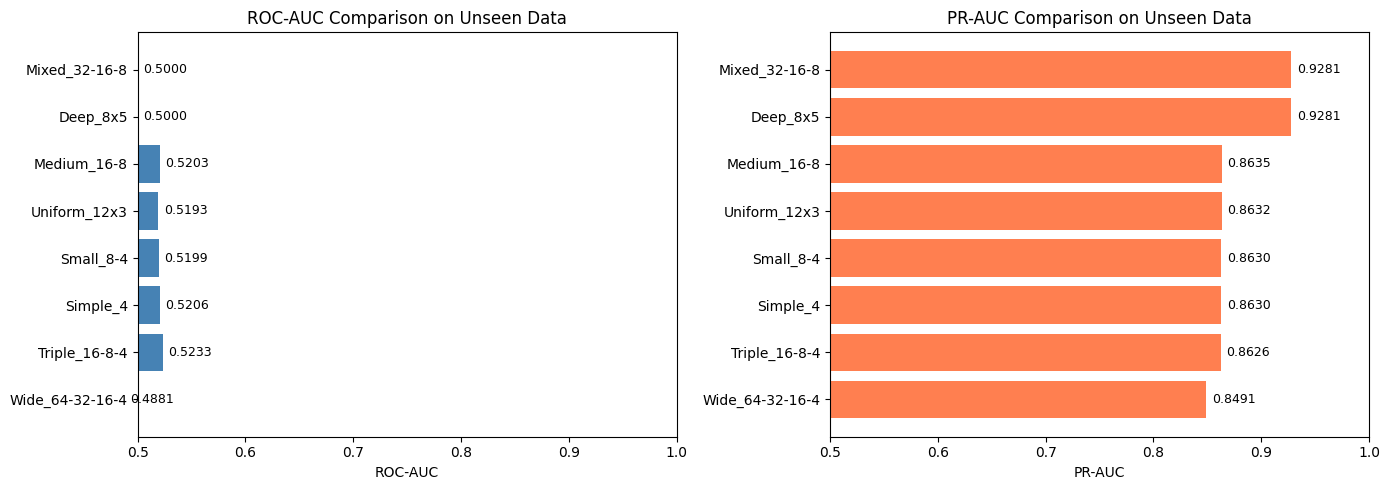

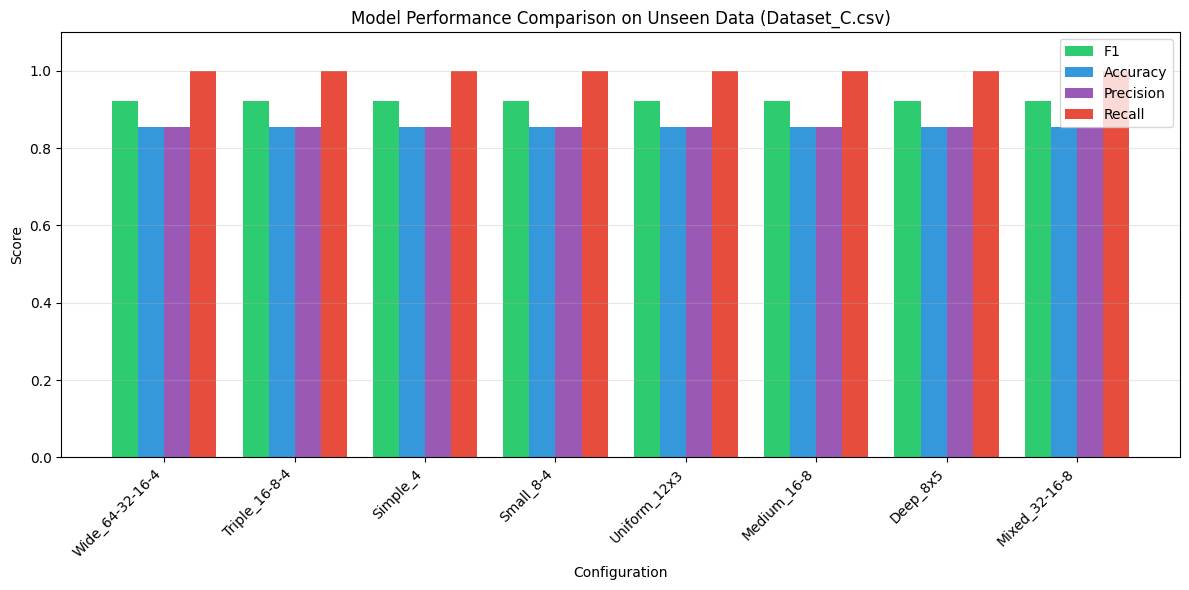

In [21]:
# Visualize comparison: ROC-AUC and PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort for better visualization
plot_df = unseen_results_df.sort_values('PR-AUC', ascending=True)

# ROC-AUC comparison
axes[0].barh(plot_df['Configuration'], plot_df['ROC-AUC'], color='steelblue')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('ROC-AUC Comparison on Unseen Data')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(plot_df['ROC-AUC']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# PR-AUC comparison
axes[1].barh(plot_df['Configuration'], plot_df['PR-AUC'], color='coral')
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('PR-AUC Comparison on Unseen Data')
axes[1].set_xlim(0.5, 1.0)
for i, v in enumerate(plot_df['PR-AUC']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# F1, Accuracy, Precision, Recall comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df))
width = 0.2

bars1 = ax.bar(x - 1.5*width, plot_df['F1'], width, label='F1', color='#2ecc71')
bars2 = ax.bar(x - 0.5*width, plot_df['Accuracy'], width, label='Accuracy', color='#3498db')
bars3 = ax.bar(x + 0.5*width, plot_df['Precision'], width, label='Precision', color='#9b59b6')
bars4 = ax.bar(x + 1.5*width, plot_df['Recall'], width, label='Recall', color='#e74c3c')

ax.set_xlabel('Configuration')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison on Unseen Data (Dataset_C.csv)')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Configuration'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step


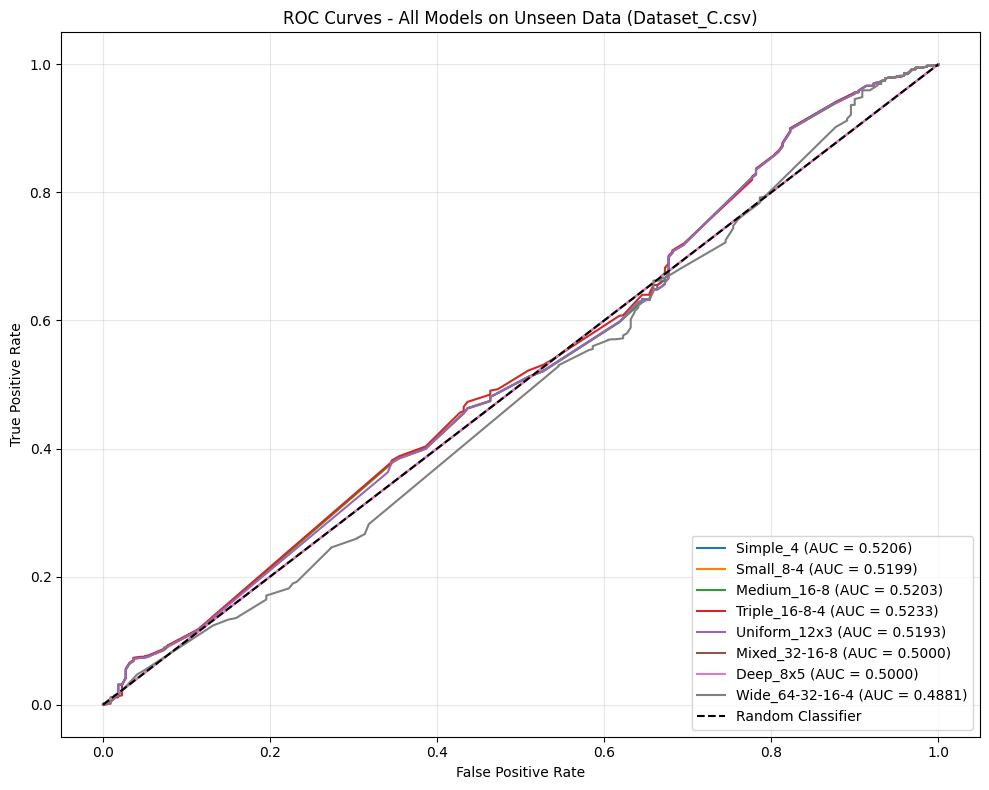

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step


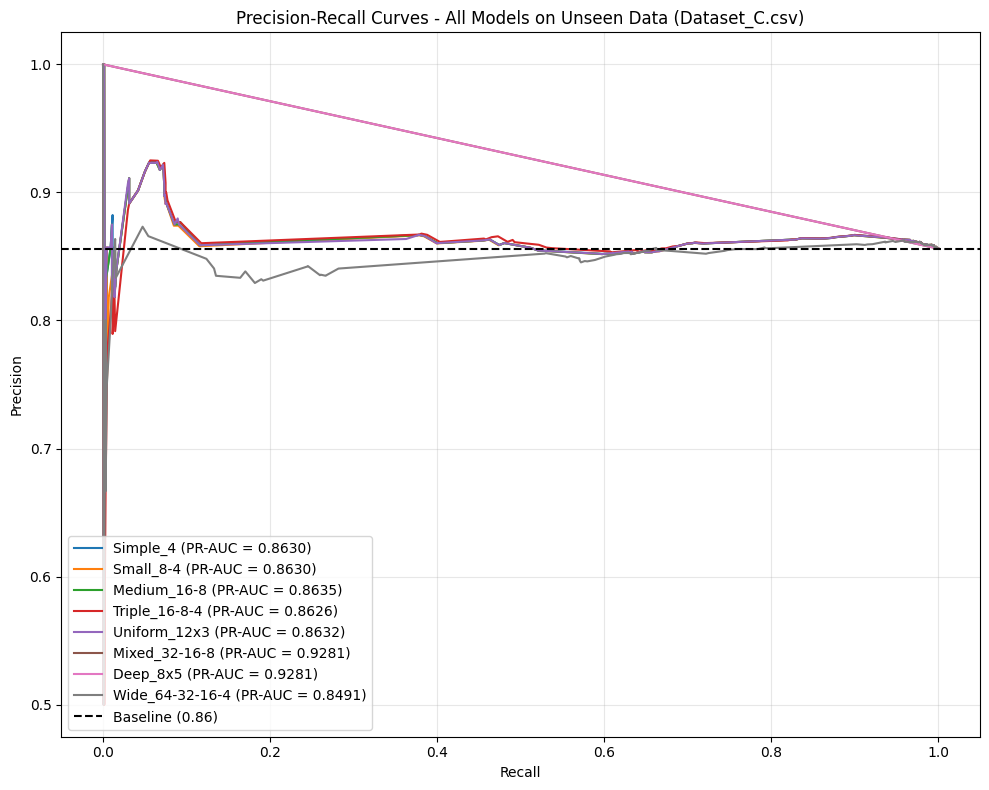

In [22]:
# Plot ROC curves for all models on unseen data
plt.figure(figsize=(10, 8))

for config_name, model in model_container.items():
    y_pred_proba = model.predict(meta_X_unseen).flatten()
    fpr, tpr, _ = roc_curve(meta_y_unseen, y_pred_proba)
    roc_auc = roc_auc_score(meta_y_unseen, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{config_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models on Unseen Data (Dataset_C.csv)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curves for all models on unseen data
plt.figure(figsize=(10, 8))

for config_name, model in model_container.items():
    y_pred_proba = model.predict(meta_X_unseen).flatten()
    precision, recall, _ = precision_recall_curve(meta_y_unseen, y_pred_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{config_name} (PR-AUC = {pr_auc:.4f})')

# Baseline (proportion of positive class)
baseline = np.mean(meta_y_unseen)
plt.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models on Unseen Data (Dataset_C.csv)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Save results to CSV
unseen_results_df.to_csv('unseen_dataset_evaluation_results.csv', index=False)
print("Results saved to 'unseen_dataset_evaluation_results.csv'")

# Display best performing model
best_model_name = unseen_results_df.iloc[0]['Configuration']
print(f"\n{'='*60}")
print(f"BEST PERFORMING MODEL ON UNSEEN DATA: {best_model_name}")
print(f"{'='*60}")
print(unseen_results_df.iloc[0].to_string())

Results saved to 'unseen_dataset_evaluation_results.csv'

BEST PERFORMING MODEL ON UNSEEN DATA: Deep_8x5
Configuration     Deep_8x5
ROC-AUC                0.5
PR-AUC            0.928058
F1                0.922481
Accuracy          0.856115
Precision         0.856115
Recall                 1.0
Avg_Precision     0.856115
Best_Threshold         0.0


In [33]:
best_config_name = "Triple_16-8-4"
best_config = configurations[best_config_name]
best_model = create_nn_model(best_config)

results = {}

print(f"Testing {best_config_name}...")
result = evaluate_nn_config(
    best_config, X_train_meta, y_train_meta, X_test_meta, y_test_meta, best_config_name
)
results[best_config_name] = result  # <-- Use string key here
# ...existing code...
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Configuration': name,
        'ROC-AUC': result['roc_auc'],
        'PR-AUC': result['pr_auc'],
        'Val_Loss': result['val_loss'],
        'Epochs': result['epochs'],
        'F1': result['F1'],
        'Best_Threshold': result['Best_Threshold'],
        'AUC': result['AUC'],
        'Average_Precision': result['Average_Precision'],
        'Accuracy': result['Accuracy']
    })

results_df = pd.DataFrame(comparison_data)
results_df = results_df.sort_values('PR-AUC', ascending=False)
print(results_df)



d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testing Triple_16-8-4...
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step
   Configuration   ROC-AUC    PR-AUC  Val_Loss  Epochs        F1  \
0  Triple_16-8-4  0.793116  0.781315  0.549314      61  0.731814   

   Best_Threshold       AUC  Average_Precision  Accuracy  
0            0.42  0.793116           0.781771  0.719908  


In [43]:
model_container['Simple_4'].compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)
#evaluate
model_container['Simple_4'].evaluate(X_test_meta, y_test_meta)
#save the model
model_container['Simple_4'].save('simple_4_model.h5')

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7281 - loss: 0.5585 - precision: 0.7431 - recall: 0.6910  
